# **Kaggle IMDB Dataset Sentiment Analysis**

## **Load Necessary Libraries**

In [5]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
!pip install contractions


[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## **Load Dataset**

In [6]:
df = pd.read_csv("../dataset/imdb_dataset.csv", engine='python', on_bad_lines='skip')

Veriseti read_csv fonksiyonu için birkaç tane okumaya uygun olmayan veri bulunduruğu için on_bad_lines parametresi kullanıldı.

In [7]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


## **Data Exploration (Initial EDA and Data Cleaning)**

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


Verisetimizde iki adet object(text) sütunu bulunmaktadır.

### **How many data we have?**

In [9]:
df.shape

(50000, 2)

Veri setinde 50000 satır ve 2 sütun bulunuyor. Bu demek oluyor ki elimizde 50000 adet text var.

In [10]:
df.size

100000

Verisetinde 100000 adet veri bulunmakta.

### **How many category and unique values do we have ?**

In [11]:
df.columns

Index(['review', 'sentiment'], dtype='str')

In [12]:
df["sentiment"].unique()

<StringArray>
['positive', 'negative']
Length: 2, dtype: str

Veriseti duygu analizi için bize iki kategori sunuyor. Positive ve Negative olmak üzere.

### **Is Dataset Balanced?**


In [13]:
df["sentiment"].value_counts(normalize=True)

sentiment
positive    0.5
negative    0.5
Name: proportion, dtype: float64

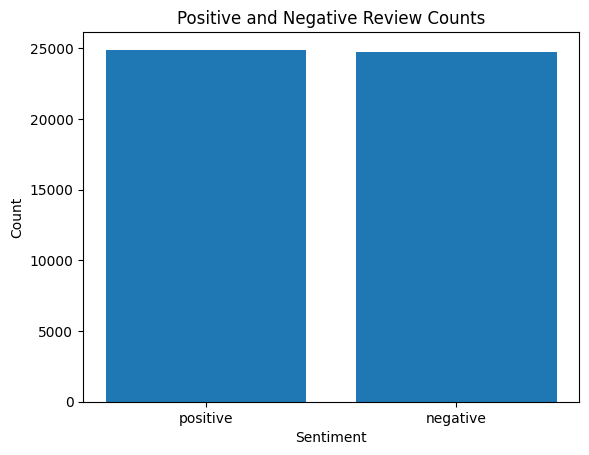

In [ ]:
counts = df["sentiment"].value_counts()

plt.bar(counts.index, counts.values)
plt.title("Positive and Negative Review Counts")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

Verisetimizde herhangi bir dengesizlik bulunmamakta. Bu bizim için iyi bir haber model eğitimi sürecinde overfitting problemi ile karşılaşma olasılığımız daha az.

### **Do we have any missing values?**

In [15]:
df.isna().sum()

review       0
sentiment    0
dtype: int64

Göründüğü kadarıyla verisetimizde herhangi kayıp veri bulunmuyor.

### **Do we have any duplicated values?**

In [16]:
duplicate_reviews = df.duplicated(subset=['review']).sum()
print(f"Aynı içeriğe sahip değerlendirme sayısı: {duplicate_reviews}")

Aynı içeriğe sahip değerlendirme sayısı: 418


Göründüğü üzere 418 adet aynı review satırına sahibiz. Bu ileride bizim overfitting problemi yaşamamıza sebep olabilir. O yüzden kurtulmak en iyisi.

In [17]:
# keep=False diyerek hem kopyaları hem de orijinalleri getiriyoruz
duplicate_rows = df[df.duplicated(keep=False)]

# Daha rahat görmek için içeriğe göre sıralayalım
duplicate_rows.sort_values(by="review").head(10)

,review,sentiment
34058,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
47467,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
29956,"""Three"" is a seriously dumb shipwreck movie. M...",negative
31488,"""Three"" is a seriously dumb shipwreck movie. M...",negative
47527,"""Witchery"" might just be the most incoherent a...",negative
2976,"""Witchery"" might just be the most incoherent a...",negative
7949,'Dead Letter Office' is a low-budget film abou...,negative
32260,'Dead Letter Office' is a low-budget film abou...,negative
18022,(Spoilers)<br /><br />Oh sure it's based on Mo...,negative
22449,(Spoilers)<br /><br />Oh sure it's based on Mo...,negative


In [18]:
df = df.drop_duplicates(subset=["review"], keep="first")
print(f"The amount of duplicated values in dataset after dropping: {df.duplicated(subset=["review"]).sum()}")

The amount of duplicated values in dataset after dropping: 0


## **Data Preprocessing**

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df["sentiment"] = le.fit_transform(df["sentiment"])

In [20]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


Sentiment sütununda bulunan string değerler integer değerlere çevrildi.

In [21]:
import pandas as pd
import re
from bs4 import BeautifulSoup
import nltk
from nltk.corpus import wordnet, stopwords
from nltk.stem import WordNetLemmatizer
import contractions

# Gerekli paketleri en başta indiriyoruz
nltk.download('averaged_perceptron_tagger')
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('stopwords')

# Temel listeyi al
stop_words = set(stopwords.words('english'))

# 1. Kısaltmaları ve yaygın internet dilini ekle
extra_stops = {
    'br', 'movie', 'film', 'acting', 'watch', 'show', 'characters',
    'story', 'plot', 'scene', 'director', 'screen', 'make', 'get',
    'one', 'would', 'could', 'even', 'really', 'also', 'see', 'time'
}

# 2. Kritik duygu kelimelerini listeden ÇIKAR (Silinmemeli!)
critical_words = {
    'not', 'no', 'nor', 'neither', 'never', 'none', 'but', 'however',
    'very', 'too', 'so', 'against', 'up', 'down'
}

# Nihai listeyi oluştur
comprehensive_stopwords = (stop_words.union(extra_stops)) - critical_words

lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    # 1. HTML Temizliği
    # Metin boşsa hata almamak için kontrol
    if not text:
        return ""

    text = BeautifulSoup(text, "html.parser").get_text()
    text = contractions.fix(text)

    # 2. Küçük harfe çevir ve sadece harfleri tut
    text = text.lower()
    text = re.sub(r'[-/]', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text) # Noktalama yerine boşluk (' ') koyduk
    text = re.sub(r'\s+', ' ', text).strip() # Birden fazla boşluğu teke indirir

    tokens = [lemmatizer.lemmatize(word) for word in text.split() if word not in comprehensive_stopwords]

    return " ".join(tokens)

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\msozg\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\msozg\AppData\Roaming\nltk_data...
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\msozg\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\msozg\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


In [22]:
df["review_clean"] = df["review"].apply(clean_text)

In [23]:
df.head()

,review,sentiment,review_clean
0,One of the other reviewers has mentioned that ...,1,reviewer mentioned watching oz episode hooked ...
1,A wonderful little production. <br /><br />The...,1,wonderful little production filming technique ...
2,I thought this was a wonderful way to spend ti...,1,thought wonderful way spend too hot summer wee...
3,Basically there's a family where a little boy ...,0,basically family little boy jake think zombie ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,petter mattei love money visually stunning mr ...


### **Vectorize the Dataset**

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=5, max_df=0.8)
X = tfidf.fit_transform(df['review_clean'])
y = df["sentiment"]


In [25]:
from sklearn.model_selection import train_test_split, GridSearchCV

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Eğitim Seti: {X_train.shape}")
print(f"Test Seti: {X_test.shape}")

Eğitim Seti: (39665, 5000)
Test Seti: (9917, 5000)


## **Model Building**

In [26]:
import sklearn.metrics as metrics
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In:
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of precision, recall, f1, accuracy, and AUC scores for your model
    '''

    preds = model.predict(X_test_data)

    auc = metrics.roc_auc_score(y_test_data, preds)
    accuracy = metrics.accuracy_score(y_test_data, preds)
    precision = metrics.precision_score(y_test_data, preds)
    recall = metrics.recall_score(y_test_data, preds)
    f1 = metrics.f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })

    return table

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

In [28]:
random_forest_model = RandomForestClassifier(random_state = 0)
logistic_model = LogisticRegression()
naive_model = MultinomialNB()
svc_model = LinearSVC()

In [29]:
random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [30]:
random_forest_model_scores = get_scores("Random Forest Classifier", random_forest_model, X_test, y_test)
random_forest_model_scores

,model,precision,recall,f1,accuracy,AUC
0,Random Forest Classifier,0.850352,0.848132,0.849241,0.848845,0.848848


In [31]:
logistic_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
logistic_model_scores = get_scores("Logistic Regression", logistic_model, X_test, y_test)
logistic_model_scores

,model,precision,recall,f1,accuracy,AUC
0,Logistic Regression,0.881074,0.903375,0.892085,0.890289,0.890238


In [33]:
naive_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [34]:
naive_model_scores = get_scores("MultinomialNB", naive_model, X_test, y_test)
naive_model_scores

,model,precision,recall,f1,accuracy,AUC
0,MultinomialNB,0.847398,0.873443,0.860224,0.857517,0.857455


In [35]:
svc_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [36]:
svc_model_scores = get_scores("LinearSVC", svc_model, X_test, y_test)
svc_model_scores

,model,precision,recall,f1,accuracy,AUC
0,LinearSVC,0.880388,0.894536,0.887405,0.886054,0.886021


In [37]:
model_scores = pd.concat([random_forest_model_scores, svc_model_scores, logistic_model_scores, naive_model_scores], ignore_index=True)
model_scores.sort_values(by="accuracy", ascending=False)

,model,precision,recall,f1,accuracy,AUC
2,Logistic Regression,0.881074,0.903375,0.892085,0.890289,0.890238
1,LinearSVC,0.880388,0.894536,0.887405,0.886054,0.886021
3,MultinomialNB,0.847398,0.873443,0.860224,0.857517,0.857455
0,Random Forest Classifier,0.850352,0.848132,0.849241,0.848845,0.848848


## LET'S TEST OUR BEST MODEL WITH OUR OWN REVIEW

In [38]:
def predict_my_review(user_text, model, vectorizer):
    # 1. Adım:Temizleme fonksiyonunu çağır
    cleaned_text = clean_text(user_text) # Daha önce yazdığımız fonksiyon

    # 2. Adım: Eğitilmiş TF-IDF ile metni sayısal vektöre çevir
    # NOT: fit_transform DEĞİL, sadece transform kullandık.
    vectorized_text = vectorizer.transform([cleaned_text])

    # 3. Adım: Tahmin yap
    prediction = model.predict(vectorized_text)[0]

    # 4. Adım: Olasılıkları gör
    # Bazı modellerde (LinearSVC gibi) predict_proba yoktur, o yüzden kontrol ediyoruz
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(vectorized_text)[0]
        confidence = max(proba) * 100
    else:
        confidence = "N/A"

    result = "POZİTİF 😊" if prediction == 1 else "NEGATİF 😞"

    print(f"\nYorum: {user_text}")
    print(f"Tahmin: {result} (Güven: %{confidence:.2f})")

In [39]:
predict_my_review("If you are looking for a movie that makes you want to stare at a blank wall for two hours instead, this is perfect for you.", logistic_model, tfidf)


Yorum: If you are looking for a movie that makes you want to stare at a blank wall for two hours instead, this is perfect for you.
Tahmin: NEGATİF 😞 (Güven: %68.26)


In [40]:
predict_my_review("The only good thing about this movie was the closing credits. Truly a masterpiece of boredom.", logistic_model, tfidf)


Yorum: The only good thing about this movie was the closing credits. Truly a masterpiece of boredom.
Tahmin: POZİTİF 😊 (Güven: %53.64)


In [41]:
predict_my_review("The acting was technically proficient and the cinematography was adequate, yet I found myself completely unable to connect with any of it. A cold, lifeless experience.", logistic_model, tfidf)


Yorum: The acting was technically proficient and the cinematography was adequate, yet I found myself completely unable to connect with any of it. A cold, lifeless experience.
Tahmin: NEGATİF 😞 (Güven: %67.75)
